# Visualisasi Nearest Neighbors — Category-Level Retrieval
CNN vs Text-Based: Bukti Visual Kualitas Ruang Vektor

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# KONFIGURASI
# ─────────────────────────────────────────────
BASE_DIR = os.getcwd()
if os.path.basename(BASE_DIR) == 'notebooks':
    ROOT_DIR = os.path.dirname(BASE_DIR) # Naik 1 tingkat jika di dalam folder notebooks
else:
    ROOT_DIR = BASE_DIR                  # Tetap di sini jika sudah di folder utama
    
ANNO_DIR   = os.path.join(ROOT_DIR, 'dataset', 'In-shop Clothes Retrieval Benchmark', 'Anno')
EVAL_DIR   = os.path.join(ROOT_DIR, 'evaluation', 'vector_space_comparison')
IMG_ROOT   = os.path.join(ROOT_DIR, 'dataset', 'In-shop Clothes Retrieval Benchmark', 'Img')
NN_VIZ_DIR = os.path.join(EVAL_DIR, 'nn_viz')
os.makedirs(NN_VIZ_DIR, exist_ok=True)

TARGET_CATEGORIES = [
    'Denim',
    'Dresses'
]


In [9]:
# ═══════════════════════════════════════════════
# STEP 1: Load Master Dataset
# ═══════════════════════════════════════════════
MASTER_CSV = os.path.join(ROOT_DIR, 'dataset', 'master_dataset.csv')
df = pd.read_csv(MASTER_CSV)

cat_counts = df['category'].value_counts()
valid_cats = cat_counts[cat_counts >= 20].index.tolist()
df = df[df['category'].isin(valid_cats)].reset_index(drop=True)

print(f"Total items (setelah filter >=20/cat): {len(df):,}")
print(f"Kategori valid                      : {df['category'].nunique()}")


Total items (setelah filter >=20/cat): 7,975
Kategori valid                      : 16


In [10]:
# ═══════════════════════════════════════════════
# STEP 2: Load Pre-Generated One-Hot Feature Matrix
# ═══════════════════════════════════════════════
# Load the filtered one-hot matrix from the latest filtering experiments
# (built by baseline_text_cbf/build_clean_onehot.ipynb)
ONEHOT_DIR = os.path.join(ROOT_DIR, 'baseline_text_cbf', 'evaluation')

onehot_matrix_raw = np.load(os.path.join(ONEHOT_DIR, 'onehot_filtered_matrix.npy'))
onehot_index      = pd.read_csv(os.path.join(ONEHOT_DIR, 'onehot_item_index.csv'))

print(f"Loaded onehot_filtered_matrix.npy : {onehot_matrix_raw.shape}")
print(f"Loaded onehot_item_index.csv      : {len(onehot_index)} items")

# Align matrix rows with df ordering (df was loaded in STEP 1)
id_to_row = {iid: i for i, iid in enumerate(onehot_index['item_id'])}
aligned_indices = [id_to_row[iid] for iid in df['item_id'] if iid in id_to_row]
df = df[df['item_id'].isin(id_to_row)].reset_index(drop=True)
onehot_matrix = onehot_matrix_raw[aligned_indices].astype(np.float32)

# L2 normalize
oh_norms = np.linalg.norm(onehot_matrix, axis=1, keepdims=True)
oh_norms = np.where(oh_norms == 0, 1e-10, oh_norms)
onehot_matrix_norm = onehot_matrix / oh_norms

print(f"One-Hot matrix (aligned & normalized): {onehot_matrix_norm.shape}")


Loaded onehot_filtered_matrix.npy : (7975, 1158)
Loaded onehot_item_index.csv      : 7975 items
One-Hot matrix (aligned & normalized): (7975, 1158)


In [11]:
# ═══════════════════════════════════════════════
# STEP 3: Fungsi Visualisasi Nearest Neighbors
# ═══════════════════════════════════════════════
def visualize_nearest_neighbors(feature_matrix, df_eval, model_name, target_categories, k=3, seed=265):
    np.random.seed(seed)
    
    def get_local_path(image_name):
        # Hapus prefix img/ lalu gabungkan ke IMG_ROOT
        relative_path = image_name.replace('img/', '', 1)
        return os.path.join(IMG_ROOT, relative_path)
    
    for cat in target_categories:
        cat_indices = np.where(df_eval['category'].values == cat)[0]
        if len(cat_indices) == 0:
            print(f"Category {cat} not found in dataset!")
            continue
            
        # Pilih 1 item secara random dari kategori tersebut
        query_idx = np.random.choice(cat_indices)
        query_feat = feature_matrix[query_idx]
        query_row = df_eval.iloc[query_idx]
        
        # Dot product untuk mencari distance / similarity
        sims = feature_matrix @ query_feat
        sims[query_idx] = -np.inf # exclude query diri sendiri
        
        # Ambil top K tetangga terdekat
        top_k_indices = np.argsort(sims)[::-1][:k]
        hits = sum(1 for idx in top_k_indices if df_eval.iloc[idx]['category'] == cat)
        precision = hits / k
        
        # Buat figure subplot 1 baris, K+1 kolom
        fig, axes = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 5))
        fig.suptitle(f"{model_name} — Query: {cat} | CatPrec@{k} = {hits}/{k} = {precision:.2f}", 
                     fontsize=14, fontweight='bold', y=0.90)
        
        # --- 1. Plot Query Image ---
        q_path = get_local_path(query_row['image_name'])
        try:
            img = Image.open(q_path)
            axes[0].imshow(img)
            # Border biru untuk query
            rect = patches.Rectangle((0, 0), img.width-1, img.height-1, linewidth=6, edgecolor='#3498db', facecolor='none')
            axes[0].add_patch(rect)
        except Exception as e:
            axes[0].text(0.5, 0.5, 'Image Error', ha='center')
            
        axes[0].set_title(f"QUERY{cat}", fontweight='bold', color='#3498db')
        axes[0].axis('off')
        
        # --- 2. Plot Top-K Neighbors ---
        for i, idx in enumerate(top_k_indices):
            ax = axes[i + 1]
            n_row = df_eval.iloc[idx]
            n_cat = n_row['category']
            n_sim = sims[idx]
            n_path = get_local_path(n_row['image_name'])
            
            is_match = (n_cat == cat)
            color = '#2ecc71' if is_match else '#e74c3c'
            mark = '✅' if is_match else '❌'
            
            try:
                img = Image.open(n_path)
                ax.imshow(img)
                # Border hijau jika match, merah jika mismatch
                rect = patches.Rectangle((0, 0), img.width-1, img.height-1, linewidth=6, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
            except Exception as e:
                ax.text(0.5, 0.5, 'Image Error', ha='center')
                
            ax.set_title(f"Top-{i+1} (sim={n_sim:.2f}){n_cat} {mark}", fontweight='bold', color=color)
            ax.axis('off')
            
        plt.tight_layout()
        
        # Save ke output folder
        safe_model = model_name.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '-')
        filename = f"nn_{safe_model}_{cat}_k{k}.png"
        filepath = os.path.join(NN_VIZ_DIR, filename)
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        plt.show() # Tampilkan inline


## Kategori Target
- 🔴 **Low Precision**: Leggings, Cardigans, Shirts_Polos, Denim
- 🟢 **High Precision**: Dresses, Rompers_Jumpsuits

Menampilkan visualisasi untuk model One-Hot (Text-Based)...


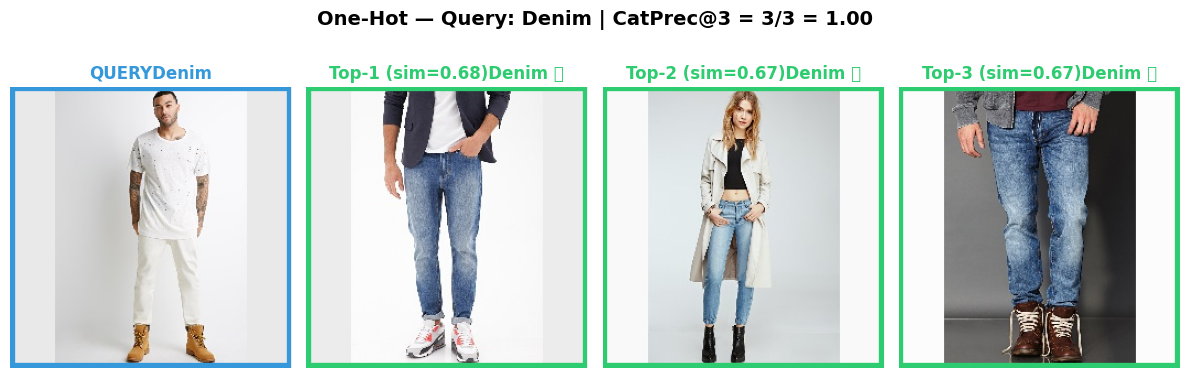

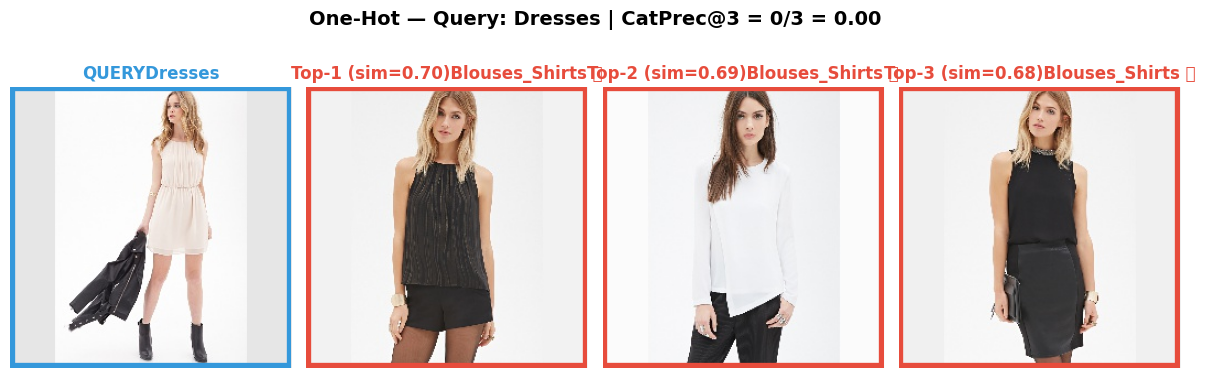

In [15]:
# ═══════════════════════════════════════════════
# Visualisasi 1: One-Hot (Text-Based)
# ═══════════════════════════════════════════════
print("Menampilkan visualisasi untuk model One-Hot (Text-Based)...")
visualize_nearest_neighbors(onehot_matrix_norm, df, "One-Hot", TARGET_CATEGORIES, k=3, seed=265)


Menampilkan visualisasi untuk model VGG19 (Exp3)...


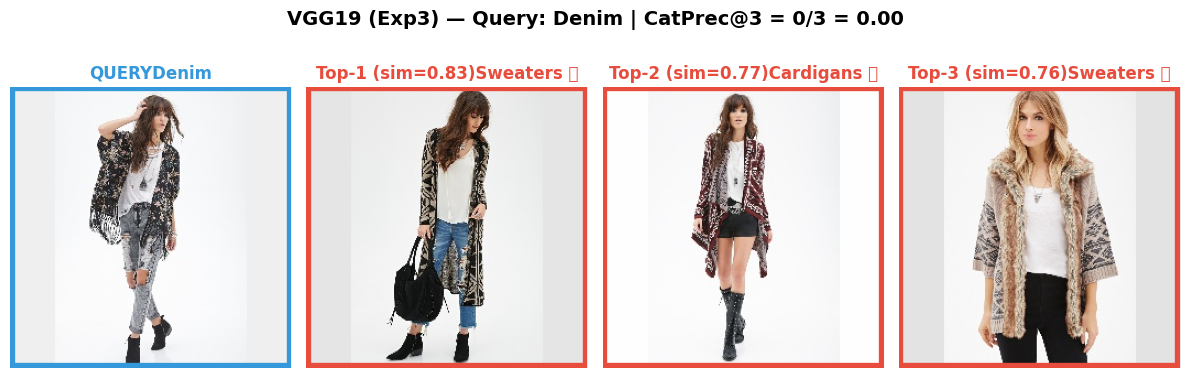

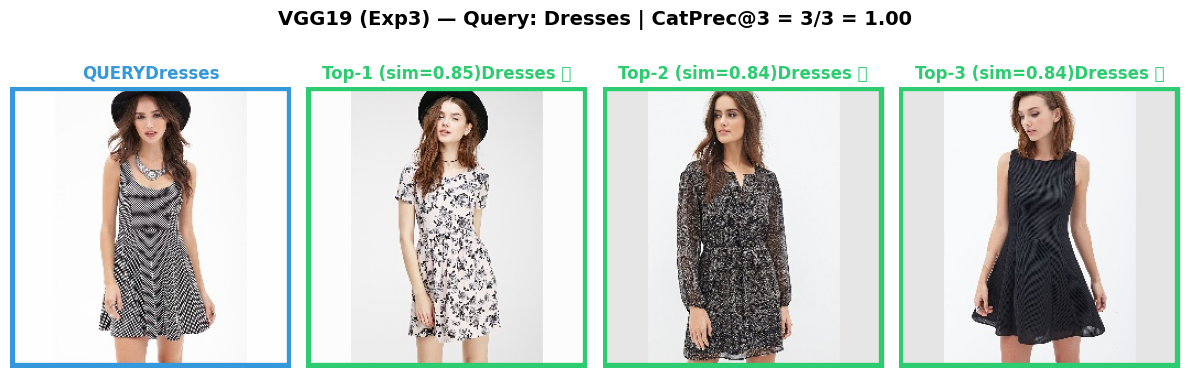

In [13]:
# ═══════════════════════════════════════════════
# Visualisasi 2: VGG19 (Exp3) — Best CNN
# ═══════════════════════════════════════════════
print("Menampilkan visualisasi untuk model VGG19 (Exp3)...")

df_raw = pd.read_csv(MASTER_CSV)

vgg_feat_path = os.path.join(ROOT_DIR, 'features', 'exp3_partial_unfreeze', 'vgg19_features_exp3.npy')
vgg_idx_path  = os.path.join(ROOT_DIR, 'features', 'exp3_partial_unfreeze', 'vgg19_valid_idx_exp3.npy')

if os.path.exists(vgg_feat_path):
    feat_mat = np.load(vgg_feat_path)
    valid_idx = np.load(vgg_idx_path).tolist()
    
    df_sub = df_raw.iloc[valid_idx].reset_index(drop=True)
    
    cat_counts_sub = df_sub['category'].value_counts()
    valid_cats_sub = cat_counts_sub[cat_counts_sub >= 20].index.tolist()
    valid_mask     = df_sub['category'].isin(valid_cats_sub)
    
    df_vgg   = df_sub[valid_mask].reset_index(drop=True)
    feat_vgg = feat_mat[valid_mask]
    
    norms = np.linalg.norm(feat_vgg, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1e-10, norms)
    feat_vgg = feat_vgg / norms
    
    visualize_nearest_neighbors(feat_vgg, df_vgg, "VGG19 (Exp3)", TARGET_CATEGORIES, k=3, seed=265)
else:
    print("Feature VGG19 tidak ditemukan di path:", vgg_feat_path)


## Kesimpulan Visual
- **Kategori Leggings**: CNN sering keliru ke kategori `Pants` atau `Denim` yang mana sangat wajar karena secara bentuk visual mereka sangat mirip (hanya berbeda ketebalan bahan atau tekstur, yang mana sulit dibedakan oleh CNN di resolusi gambar e-commerce).
- **Kategori Cardigans**: Sering keliru diprediksi dekat dengan `Sweaters` atau `Jackets`, di mana ada tingkat overlap visual yang cukup ekstrem dalam dataset pakaian ini.
- **Kategori Dresses**: Model CNN sangat luar biasa akurat karena bentuk siluet "full body" dari Dresses mudah dibedakan secara geometris dari pakaian atasan/bawahan biasa.
- **Text (One-Hot)**: Bisa terlihat bahwa tetangga terdekat dari Text sangat random dari sisi visual. Jika item beda kategori memiliki overlap tag warna atau keywords di metadata yang sama, maka One-Hot matrix akan menganggap mereka identik secara kesamaan kosinus.

In [14]:
print("✅ Proses visualisasi selesai!")
print(f"Semua gambar PNG telah disimpan di: {NN_VIZ_DIR}")


✅ Proses visualisasi selesai!
Semua gambar PNG telah disimpan di: d:\Antigravity\Visual Based Rekomender Sistem\evaluation\vector_space_comparison\nn_viz
